## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [21]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
df = pd.read_csv(url)

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [23]:
df_tidy = df.drop(columns=['total_litres_of_pure_alcohol'])
df_tidy = df_tidy.melt(id_vars='country', var_name='drink', value_name='servings')

df_tidy.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [24]:
df_tidy["drink"] = df_tidy["drink"].str.replace("_servings", "")

In [25]:
top_beer = df_tidy[df_tidy["drink"] == "beer"].nlargest(10, "servings")
top_wine = df_tidy[df_tidy["drink"] == "wine"].nlargest(10, "servings")
top_spirit = df_tidy[df_tidy["drink"] == "spirit"].nlargest(10, "servings")

print("\nTop Beer Countries:\n", top_beer[["country", "servings"]])
print("\nTop Wine Countries:\n", top_wine[["country", "servings"]])
print("\nTop Spirit Countries:\n", top_spirit[["country", "servings"]])


Top Beer Countries:
             country  servings
117         Namibia       376
45   Czech Republic       361
62            Gabon       347
65          Germany       346
98        Lithuania       343
135          Poland       343
188       Venezuela       333
81          Ireland       313
129           Palau       306
140         Romania       297

Top Wine Countries:
                country  servings
447             France       370
522           Portugal       339
389            Andorra       312
552        Switzerland       280
434            Denmark       278
542           Slovenia       276
485         Luxembourg       271
428            Croatia       254
469              Italy       237
441  Equatorial Guinea       233

Top Spirit Countries:
                 country  servings
261             Grenada       438
208             Belarus       373
266               Haiti       326
334  Russian Federation       326
337           St. Lucia       315
265              Guyana       302
3

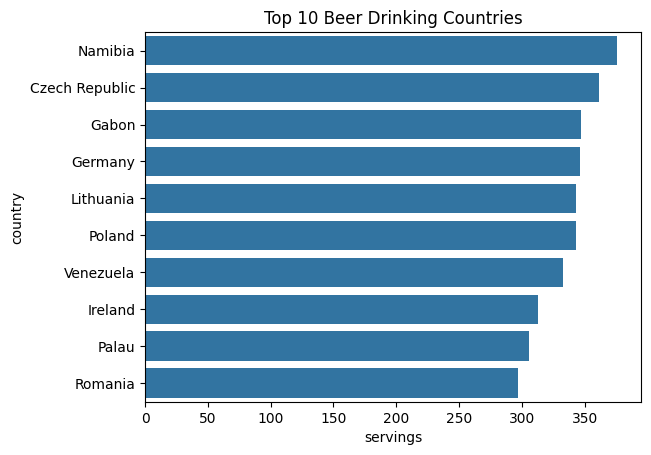

In [26]:
# Plot Beer
plt.figure()
sns.barplot(data=top_beer, x="servings", y="country")
plt.title("Top 10 Beer Drinking Countries")
plt.show()

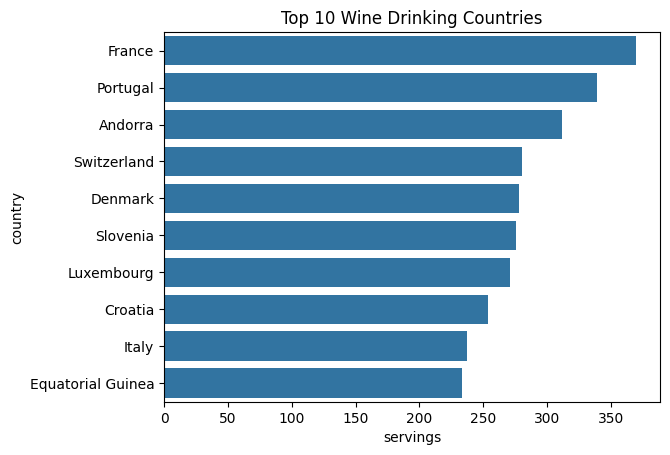

In [27]:
# Plot Wine
plt.figure()
sns.barplot(data=top_wine, x="servings", y="country")
plt.title("Top 10 Wine Drinking Countries")
plt.show()

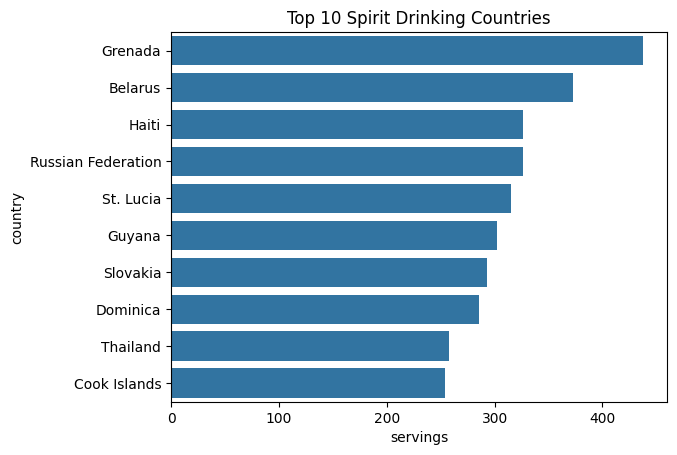

In [28]:
# Plot Spirits
plt.figure()
sns.barplot(data=top_spirit, x="servings", y="country")
plt.title("Top 10 Spirit Drinking Countries")
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [29]:
df_wide = df_tidy.pivot_table(
    index = "country",
    columns = "drink",
    values = "servings"
)

df_wide.head()

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
